In [1]:
import pandas as pd
import json
from pathlib import Path
import requests
import os
import glob

In [184]:
# Load the provinces data from the tat_thai_provinces.json file
with open('../../dataset/tat_v1_provinces.json', 'r', encoding='utf-8') as f:
    provinces = json.load(f)

# API key for authentication
API_KEY = 'UmYQ8yiaTyArXEN5GMRJiCcvtu99ILDd'

# API Key for tripadvisor
TRIPADVISOR_API_KEY = 'FDB8183A632245CDA0EC0DBF74159030'

# Base URL for fetching attractions list
BASE_URL = 'https://tatdataapi.io/api/v1/places'

TRIPADVISOR_BASE_URL = 'https://api.content.tripadvisor.com/api/v1/location'

LANGUAGE = 'th'

# Headers for the API request
headers = {
    'accept': 'application/json',
    'Accept-Language': LANGUAGE,
    'x-api-key': API_KEY,
}


In [ ]:
# Loop through each province and fetch the data
for province in provinces:
    province_id = province['provinceId']
    province_name = province['name']
    
    # Prepare the parameters for the API request
    params = {
        'provinceId': province_id,
        # 'place_category_id': 3,  # You can change this if necessary
        'pageSize': 100, # For V1
        # 'page': 1,
        'pageNumber': 1, # For V1
        # 'sort_by': 'placeId',
        # 'categoryCode': 'attractions' # For V2
        'categoryCode': 'attraction' # For V1
    }
    
    # Send the GET request to fetch the attractions
    response = requests.get(BASE_URL, headers=headers, params=params)
    
    if response.status_code == 200:
        # Convert the response to JSON
        data = response.json()
        
        # Check if 'data' is available in the response
        if 'data' in data:
            attractions = data['data']
            
            # Transform the data into a DataFrame
            records = []
            for item in attractions:
                location = item.get("location", {})
                tags = item.get("tags", [])
                category = item.get("category", {})
                province = location.get("province", {})
                district = location.get("district", {})
                sub_district = location.get("subDistrict", {})
                
                record = {
                    "placeId": item.get("placeId"),
                    "place_name": item.get("name"),
                    "introduction": item.get("introduction"),
                    "category_name": category.get("name"),
                    "categoryId": category.get("categoryId"),
                    "latitude": item.get("latitude"),
                    "longitude": item.get("longitude"),
                    "postcode": location.get("postcode") if location else None,
                    "thumbnail_url": item.get("thumbnailUrl", [None])[0] if item.get("thumbnailUrl") else None,
                    "tags": ",".join(tags) if tags else "",  # Safely handle tags
                    "province_Id": province.get("provinceId") if province else None,
                    "province_name": province.get("name") if province else None,
                    "district_Id": district.get("districtId") if district else None,
                    "district_name": district.get("name") if district else None,
                    "sub_district_Id": sub_district.get("subDistrictId") if sub_district else None,
                    "sub_district_name": sub_district.get("name") if sub_district else None,
                    "updated_at": item.get("updatedAt"),
                }
                records.append(record)
            
            # Create a DataFrame
            df = pd.DataFrame(records)
            
            # Save the DataFrame to a CSV file
            csv_filename = f"data/{province_id}_attractions_{LANGUAGE}.csv"
            df.to_csv(csv_filename, index=False, encoding='utf-8')
            print(f"Data for {province_name} saved to {csv_filename}")
        else:
            print(f"No data found for {province_name} (ID: {province_id})")
    else:
        print(f"Failed to fetch data for {province_name} (ID: {province_id})")

In [ ]:
# Directory where the CSV files are stored (you can set this to the path where your CSV files are)
csv_directory = './data/'  # Assuming the files are in the current working directory

# Initialize an empty list to hold DataFrames
df_list = []

# Loop through all CSV files in the directory
for filename in os.listdir(csv_directory):
    if filename.endswith(f"_attractions_{LANGUAGE}.csv"):  # Only process the relevant CSV files
        file_path = os.path.join(csv_directory, filename)
        
        # Read each CSV file into a DataFrame and append it to the list
        df = pd.read_csv(file_path)
        df_list.append(df)

# Concatenate all DataFrames into one
merged_df = pd.concat(df_list, ignore_index=True)

# Save the merged DataFrame to a single CSV file
merged_df.to_csv(f"tat_attractions_{LANGUAGE}.csv", index=False, encoding='utf-8')

print(f"All files have been merged into 'tat_attractions_{LANGUAGE}.csv'")

In [5]:
# Define the path to the JSON file
json_file = Path("../../dataset/tat_attractions.json")

# Check if the file exists
if not json_file.is_file():
    raise FileNotFoundError(f"The file '{json_file}' does not exist. Please provide the correct file path.")

# Load the JSON file
with json_file.open('r', encoding='utf-8') as file:
    data = json.load(file)

In [7]:

records = []
for item in data['data']:  # Added safeguard for 'data' key
    if not item:  # Ensure item is not None or empty
        continue
    
    location = item.get("location", {})  # Safe way to access location, defaults to empty dict if None
    tags = item.get("tags", [])  # Ensure tags defaults to an empty list
    category = item.get("category", {})  # Ensure category defaults to an empty dict
    province = location.get("province", {})  # Safely get province
    district = location.get("district", {})  # Safely get district
    sub_district = location.get("subDistrict", {})  # Safely get subDistrict
    
    record = {
        "placeId": item.get("placeId"),
        "place_name": item.get("name"),
        "introduction": item.get("introduction"),
        "category_name": category.get("name"),  # Safely access category name
        "categoryId": category.get("categoryId"),  # Safely access category ID
        "latitude": item.get("latitude"),
        "longitude": item.get("longitude"),
        "postcode": location.get("postcode") if location else None,
        "thumbnail_url": item.get("thumbnailUrl", [None])[0] if item.get("thumbnailUrl") else None,
        "tags": ",".join(tags) if tags else "",  # Safely handle tags and avoid errors when None
        "province_Id": province.get("provinceId") if province else None,  # Safely get province ID
        "province_name": province.get("name") if province else None,  # Safely get province name
        "district_Id": district.get("districtId") if district else None,  # Safely get district ID
        "district_name": district.get("name") if district else None,  # Safely get district name
        "sub_district_Id": sub_district.get("subDistrictId") if sub_district else None,  # Safely get sub-district ID
        "sub_district_name": sub_district.get("name") if sub_district else None,  # Safely get sub-district name
        "updated_at": item.get("updatedAt"),
    }
    records.append(record)

# Create a DataFrame from the extracted records
df = pd.DataFrame(records)

# Save the DataFrame to a CSV file (optional)
df.to_csv("tat_attractions.csv", index=False, encoding='utf-8')

# Display the DataFrame to verify
print(df.head())

  placeId                             place_name  \
0    1858  วัดสระเกศ ราชวรมหาวิหาร (วัดภูเขาทอง)   
1   33400               ศาลเจ้าพ่อ-เจ้าแม่ชุมแสง   
2   33586                   ตลาดเก่าร้อยปีชุมแสง   
3   33885                            ตลาดเจ้าค่ะ   
4   33325                 อุทยานเทวสถานพระพิฆเนศ   

                                        introduction      category_name  \
0  วัดสระเกศ หรือ วัดภูเขาทอง (Temple of the Gold...  สถานที่ท่องเที่ยว   
1                                               None  สถานที่ท่องเที่ยว   
2                                               None  สถานที่ท่องเที่ยว   
3  ตั้งอยู่ตำบลเขาดิน บริเวณริมแม่น้ำปิงด้านหน้าว...  สถานที่ท่องเที่ยว   
4                                               None  สถานที่ท่องเที่ยว   

   categoryId  latitude  longitude postcode  \
0           3  13.75389  100.50841    10100   
1           3  15.89933  100.30886    60120   
2           3  15.89541  100.30847    60120   
3           3  15.81700  100.07715    60230   
4

In [6]:
EN_Attractions_df = pd.read_csv('./tat_attractions_en.csv')
TH_Attractions_df = pd.read_csv('./tat_attractions_th.csv')

In [7]:
TH_Attractions_df.head(5)

,placeId,place_name,introduction,category_name,categoryId,latitude,longitude,postcode,thumbnail_url,tags,province_Id,province_name,district_Id,district_name,sub_district_Id,sub_district_name,updated_at
0,P03012583,ถ้ำมโหฬาร,อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัด...,สถานที่ท่องเที่ยว,3,17.10731,101.87997,42190.0,h,NaN,576,เลย,4214.0,หนองหิน,5102.0,หนองหิน,2024-07-16T20:03:56.009Z
1,P03014048,เสมาหินทราย บ้านปากแบ่งและบ้านนาหลัก,ที่บ้านนาหลัก เป็นเสมาหินปักคู่สองหลัก แบบที่ม...,สถานที่ท่องเที่ยว,3,17.48602,101.72230,42000.0,h,NaN,576,เลย,4201.0,เมืองเลย,4994.0,กุดป่อง,2024-07-16T20:03:55.442Z
2,P03025545,ศูนย์บริการนักท่องเที่ยววังกวาง,เป็นลานกางเต็นท์และบ้านพักของอุทยานฯ ซึ่งตั้งอ...,สถานที่ท่องเที่ยว,3,16.88681,101.78800,42180.0,h,NaN,576,เลย,4210.0,ภูกระดึง,5076.0,ศรีฐาน,2024-07-16T20:03:51.616Z
3,P03012596,อุทยานแห่งชาติภูสวนทราย,เป็นป่าดิบเขาเป็นพรมแดนธรรมชาติระหว่างแผ่นดินไ...,สถานที่ท่องเที่ยว,3,17.50356,100.93892,42170.0,h,อุทยานแห่งชาติภูสวนทราย,576,เลย,4206.0,นาแห้ว,5044.0,แสงภา,2024-07-16T20:03:51.358Z
4,P03001063,วัดท่าแขก วัดโบราณ,เป็นวัดเก่าแก่อยู่ริมฝั่งแม่น้ำโขง ห่างจากอำเภ...,สถานที่ท่องเที่ยว,3,17.90506,101.68336,42110.0,h,NaN,576,เลย,4203.0,เชียงคาน,5012.0,เชียงคาน,2024-07-16T20:03:50.031Z


In [8]:
EN_Attractions_df.head(5)

,placeId,place_name,introduction,category_name,categoryId,latitude,longitude,postcode,thumbnail_url,tags,province_Id,province_name,district_Id,district_name,sub_district_Id,sub_district_name,updated_at
0,P03018449,Old Town by Phetchaburi’s River CBT,NaN,Attraction,3,13.10722,99.94842,76000.0,h,"เพชรบุรี,ย่านเมืองเก่า",228,Phetchaburi,7601.0,Mueang Phetchaburi,8421.0,Khlong Krachaeng,2024-08-01T20:00:06.292Z
1,P03013153,Kwangchow Floating Market,NaN,Attraction,3,13.11103,99.63627,76160.0,h,NaN,228,Phetchaburi,7603.0,Nong Ya Plong,8459.0,Yang Nam Klat Nuea,2024-07-16T20:03:55.831Z
2,P03014487,Wat Khoi,NaN,Attraction,3,13.10870,99.94154,76000.0,h,"พระธาตุฉิมพลีพระเศรษฐีนวโกฏิ ,เพชรบุรี,วัดข่อย",228,Phetchaburi,7601.0,Mueang Phetchaburi,8421.0,Khlong Krachaeng,2024-07-16T20:03:50.833Z
3,P03013393,Hat Chao Samran,"This beach, which is located approximately 15 ...",Attraction,3,13.00624,100.06602,76100.0,h,NaN,228,Phetchaburi,7601.0,Mueang Phetchaburi,8436.0,Hat Chao Samran,2024-07-16T20:03:47.548Z
4,P03008661,Laem Leaw,NaN,Attraction,3,13.22476,99.99306,76110.0,h,NaN,228,Phetchaburi,7607.0,Ban Laem,8510.0,Ban Laem,2024-07-16T20:03:42.554Z


In [9]:
TH_Attractions_df['placeId'] = TH_Attractions_df['placeId'].astype(str)
EN_Attractions_df['placeId'] = EN_Attractions_df['placeId'].astype(str)

TH_Attractions_df.rename(columns={'introduction': 'introduction_th'}, inplace=True)
TH_Attractions_df.rename(columns={'place_name': 'place_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'province_name': 'province_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'district_name': 'district_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'sub_district_name': 'sub_district_name_th'}, inplace=True)
Merge_Attractions_df = TH_Attractions_df.merge(EN_Attractions_df[['placeId', 'introduction', 'place_name', 'province_name', 'district_name', 'sub_district_name']], on='placeId', how='left')
Merge_Attractions_df.rename(columns={'introduction': 'introduction_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'place_name': 'place_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'province_name': 'province_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'district_name': 'district_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'sub_district_name': 'sub_district_name_en'}, inplace=True)

Merge_Attractions_df['introduction_en'].fillna('-')
Merge_Attractions_df['introduction_th'].fillna('-')

0       อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัด...
1       ที่บ้านนาหลัก เป็นเสมาหินปักคู่สองหลัก แบบที่ม...
2       เป็นลานกางเต็นท์และบ้านพักของอุทยานฯ ซึ่งตั้งอ...
3       เป็นป่าดิบเขาเป็นพรมแดนธรรมชาติระหว่างแผ่นดินไ...
4       เป็นวัดเก่าแก่อยู่ริมฝั่งแม่น้ำโขง ห่างจากอำเภ...
                              ...                        
4320                                                    -
4321    ประดิษฐาน "พระบาง" พระพุทธรูปสำคัญคู่บ้านคู่เม...
4322                                                    -
4323                                                    -
4324                                                    -
Name: introduction_th, Length: 4325, dtype: object

In [ ]:
Merge_Attractions_df.info()

In [ ]:
Merge_Attractions_df.head(5)

In [ ]:
Merge_Attractions_df.to_csv('./merged_tat_attractions.csv', index=False, encoding='utf-8')

In [185]:
Merge_Attractions_df = pd.read_csv("./merged_tat_attractions.csv")

In [186]:
Merge_Attractions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   placeId               4325 non-null   object 
 1   place_name_th         4324 non-null   object 
 2   introduction_th       2546 non-null   object 
 3   category_name         4325 non-null   object 
 4   categoryId            4325 non-null   int64  
 5   latitude              4313 non-null   float64
 6   longitude             4313 non-null   float64
 7   postcode              4215 non-null   float64
 8   thumbnail_url         3601 non-null   object 
 9   tags                  857 non-null    object 
 10  province_Id           4325 non-null   int64  
 11  province_name_th      4325 non-null   object 
 12  district_Id           4317 non-null   float64
 13  district_name_th      4317 non-null   object 
 14  sub_district_Id       4217 non-null   float64
 15  sub_district_name_th 

In [187]:

def fetch_tripvisor_attractions(attraction_df, filter_df = []):
    records = []
    
    for index, attraction in attraction_df.iterrows():
        if len(filter_df) > 0 and attraction.placeId in filter_df["place_id"].values:
            continue
        
        # Handle language-specific fields
        province_name = attraction.province_name_th
        place_name = attraction.place_name_th
        latLong = f"{attraction.latitude}, {attraction.longitude}"
        address = 'Thailand'
        # address = f"{attraction.province_name_th} {attraction.district_name_th} {attraction.sub_district_name_th} {attraction.postcode}"
        if LANGUAGE == 'en':
            province_name = attraction.province_name_en or province_name
            place_name = attraction.place_name_en or place_name
            
            
        print(f"\n #{index + 1} ===== Processing attraction: {place_name} in province {province_name} [{latLong}] [{address}]")

        # Prepare the parameters for the API request
        params = {
            'key': TRIPADVISOR_API_KEY,
            'searchQuery': place_name,
            'language': LANGUAGE,
            'address': address,
            'category': 'attractions',
            # 'latLong': latLong
        }

        try:
            # Send the GET request to fetch the attractions
            response = requests.get(f"{TRIPADVISOR_BASE_URL}/search", headers=headers, params=params)

            # Debug: Print request and response details
            print(f"Request URL: {response.url}")
            print(f"Response Status Code: {response.status_code}")
            
            # Stop loop on critical error (status codes in 4xx or 5xx range)
            if response.status_code >= 400:
                print(f"Critical error encountered! Status code: {response.status_code}")
                # break

            if response.status_code == 200:
                # Convert the response to JSON
                data = response.json()
                print(f"Response Content: {data}")  # Debug: Print the full JSON response

                # Check if 'data' is available in the response
                if 'data' in data and data['data']:
                    attractions = data['data']

                    # Process attractions
                    for item in attractions:
                        
                        if len(filter_df) > 0 and  item.get("location_id") in filter_df["location_id"].values:
                            continue
    
                        addressObj = item.get("address_obj", {})
                        record = {
                            "place_id": attraction.placeId,
                            "location_id": item.get("location_id"),
                            "name": item.get("name"),
                            "state": addressObj.get("postalcode") if addressObj.get("state") else pd.NA,
                            "country": addressObj.get("country"),
                            "postalcode": addressObj.get("postalcode") if addressObj.get("postalcode") else pd.NA,
                        }
                        records.append(record)
                else:
                    print(f"No data found for {place_name} in {province_name}")
            else:
                print(f"API request failed with status code {response.status_code} for {place_name} in {province_name}")
        except Exception as e:
            print(f"An error occurred for {place_name} in {province_name}: {e}")

    return records



In [65]:
len(Merge_Attractions_df)

4325

In [190]:
OFFSET = 1

In [191]:
records = fetch_tripvisor_attractions(Merge_Attractions_df[500 * (OFFSET - 1):500 * OFFSET])


 #1 ===== Processing attraction: ถ้ำมโหฬาร in province เลย [17.10731, 101.87997] [Thailand]
Request URL: https://api.content.tripadvisor.com/api/v1/location/search?key=FDB8183A632245CDA0EC0DBF74159030&searchQuery=%E0%B8%96%E0%B9%89%E0%B8%B3%E0%B8%A1%E0%B9%82%E0%B8%AB%E0%B8%AC%E0%B8%B2%E0%B8%A3&language=th&address=Thailand&category=attractions
Response Status Code: 200
Response Content: {'data': []}
No data found for ถ้ำมโหฬาร in เลย

 #2 ===== Processing attraction: เสมาหินทราย บ้านปากแบ่งและบ้านนาหลัก in province เลย [17.48602, 101.7223] [Thailand]
Request URL: https://api.content.tripadvisor.com/api/v1/location/search?key=FDB8183A632245CDA0EC0DBF74159030&searchQuery=%E0%B9%80%E0%B8%AA%E0%B8%A1%E0%B8%B2%E0%B8%AB%E0%B8%B4%E0%B8%99%E0%B8%97%E0%B8%A3%E0%B8%B2%E0%B8%A2+%E0%B8%9A%E0%B9%89%E0%B8%B2%E0%B8%99%E0%B8%9B%E0%B8%B2%E0%B8%81%E0%B9%81%E0%B8%9A%E0%B9%88%E0%B8%87%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%9A%E0%B9%89%E0%B8%B2%E0%B8%99%E0%B8%99%E0%B8%B2%E0%B8%AB%E0%B8%A5%E0%B8%B1%E0%B8%81&langu

KeyboardInterrupt: 

In [74]:
len(records)

2085

In [75]:
tripadvisor_attractions_locations = pd.DataFrame(records)

In [76]:
tripadvisor_attractions_locations.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2085 entries, 0 to 2084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   place_id     2085 non-null   object
 1   location_id  2085 non-null   object
 2   name         2085 non-null   object
 3   state        1432 non-null   object
 4   country      2085 non-null   object
 5   postalcode   1530 non-null   object
dtypes: object(6)
memory usage: 97.9+ KB


In [77]:
tripadvisor_attractions_locations = tripadvisor_attractions_locations[~tripadvisor_attractions_locations["location_id"].duplicated(keep=False)]


In [78]:
tripadvisor_attractions_locations

,place_id,location_id,name,state,country,postalcode
1,P03014357,19125783,Wat Pa Lahan Sai,31170,Thailand,31170
4,P03025899,13376335,NARA Massage & Spa Phuket,83130,Thailand,83130
5,P03025899,11893486,Wat Bang Nara,None,Thailand,<NA>
6,P03006742,4322957,Hala-Bala Wildlife Sanctuary,None,Thailand,<NA>
7,P03006742,8874192,Hala-Bala Wildlife Sanctuary,96190,Thailand,96190
...,...,...,...,...,...,...
1999,P03014033,6669347,Wat Songtham Worawihan,10131,Thailand,10131
2000,P03014033,12841564,Wat Thewarup Songtham,30310,Thailand,30310
2005,P03014033,23763543,Wat Simalai Songtham,30130,Thailand,30130
2014,P03011565,25009062,Phu Man Fah Monastery,31110,Thailand,31110


In [79]:
tripadvisor_attractions_locations.to_csv(f'data/tripadvisor_locations_{OFFSET}.csv')

In [103]:

folder_path = "data"
file_pattern = "tripadvisor_locations_*.csv"

# Find all files matching the pattern
file_paths = glob.glob(os.path.join(folder_path, file_pattern))

# Load the files into a list of DataFrames
dataframes = [pd.read_csv(file) for file in file_paths]

# Optionally, combine all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes, ignore_index=True)

In [111]:
combined_df.to_csv("data/tripadvisor_locations_all.csv")

In [106]:
all_tripadvisor_attractions_locations = combined_df[~combined_df["location_id"].duplicated(keep=False)]


In [109]:
all_tripadvisor_attractions_locations

,Unnamed: 0,place_id,location_id,name,state,country,postalcode,Unnamed: 0.1


In [94]:
all_tripadvisor_attractions_locations.to_csv("data/tripadvisor_locations_avaiable.csv")

In [88]:
filtered_missing_attraction_df = Merge_Attractions_df[
    ~Merge_Attractions_df["placeId"].isin(all_tripadvisor_attractions_locations["place_id"])
]

In [91]:
filtered_missing_attraction_df.to_csv("data/tat_locations_not_available.csv")

In [95]:
filtered_merge = Merge_Attractions_df[
    ~Merge_Attractions_df["placeId"].isin(all_tripadvisor_attractions_locations["place_id"])
]

In [97]:
place_id_set = set(all_tripadvisor_attractions_locations["place_id"])
filtered_merge = Merge_Attractions_df[
    Merge_Attractions_df["placeId"].isin(place_id_set)
]

In [99]:
filtered_merge.to_csv("data/tat_locations_available.csv")

In [5]:
all_tripadvisor_attractions_locations = pd.read_csv("data/tripadvisor_locations_avaiable.csv")

In [6]:
all_tripadvisor_attractions_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1907 entries, 0 to 1906
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  1907 non-null   int64 
 1   Unnamed: 0    1907 non-null   int64 
 2   place_id      1907 non-null   object
 3   location_id   1907 non-null   int64 
 4   name          1907 non-null   object
 5   state         1149 non-null   object
 6   country       1907 non-null   object
 7   postalcode    1315 non-null   object
dtypes: int64(3), object(5)
memory usage: 119.3+ KB


In [7]:
all_tripadvisor_attractions_locations = all_tripadvisor_attractions_locations.drop(
    columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore"
)

In [8]:
all_tripadvisor_attractions_locations

,place_id,location_id,name,state,country,postalcode
0,P03003665,456633,House of Opium,57150.0,Thailand,57150.0
1,P03003665,23933132,Opium Bar,NaN,Thailand,10100.0
2,P03003590,7099963,Wat Phra That Doi Saket,50220.0,Thailand,50220.0
3,P03002324,1390125,Mae Ping River Cruise,50100.0,Thailand,50100.0
4,P03002324,547675,Pai River,NaN,Thailand,NaN
...,...,...,...,...,...,...
1902,P03017171,8647002,Nang Lae Nai Waterfall,NaN,Thailand,NaN
1903,P01000743,24105261,San Chao Rong Thong Market,NaN,Thailand,NaN
1904,P03018527,8328708,Cha's Bar,NaN,Thailand,10200.0
1905,P03018527,23208562,The Gundam Base Thailand Gallery,NaN,Thailand,10400.0


In [10]:

def fetch_tripvisor_attractions_details(attraction_df, filter_df = []):
    records = []
    
    for index, attraction in attraction_df.iterrows():
        if len(filter_df) > 0 and attraction.placeId in filter_df["place_id"].values:
            continue
        
        currency = 'THB'
        if LANGUAGE == 'en':
            currency = 'USD'
            
        print(f"\n #{index + 1} ===== Processing attraction: <{attraction.location_id}> {attraction.name} in province [{attraction.place_id}]")

        params = {
            'key': TRIPADVISOR_API_KEY,
            'language': LANGUAGE,
            'currency': currency,
        }

        try:
            response = requests.get(f"{TRIPADVISOR_BASE_URL}/{attraction.location_id}/details", headers=headers, params=params)

            print(f"Request URL: {response.url}")
            print(f"Response Status Code: {response.status_code}")
            
            if response.status_code >= 400:
                print(f"Critical error encountered! Status code: {response.status_code}")
                # break

            if response.status_code == 200:
                data = response.json()
                print(f"Response Content: {data}") 

                if data :
                    rankingObj = data.get("ranking_data", {})
                    reviewRatingObj = data.get("review_rating_count", {})
                    
                    categories_string = ""
                    
                    if len(data["groups"]) > 0:
                        for index, group in enumerate(data["groups"]):
                            categories_string = ", ".join(category["name"] for category in group["categories"])
                            
                    
                    detail = {
                        "location_id": data.get("location_id", pd.NA),
                        "name": data.get("name", pd.NA),
                        "description": data.get("description", pd.NA),  # Handles missing 'description'
                        "web_url": data.get("web_url", pd.NA),
                        "latitude": data.get("latitude", pd.NA),
                        "longitude": data.get("longitude", pd.NA),
                        "website": data.get("website", pd.NA),
                        "write_review": data.get("write_review", pd.NA),
                        "rating": data.get("rating", 0),
                        "rating_image_url": data.get("rating_image_url", pd.NA),
                        "num_reviews": data.get("num_reviews", 0),
                        "ranking_geo_location_id": rankingObj.get("geo_location_id") if rankingObj.get("geo_location_id") else pd.NA,
                        "ranking_string": rankingObj.get("ranking_string") if rankingObj.get("ranking_string") else pd.NA,
                        "geo_location_name": rankingObj.get("geo_location_name") if rankingObj.get("geo_location_name") else pd.NA,
                        "ranking_out_of": rankingObj.get("ranking_out_of") if rankingObj.get("ranking_out_of") else pd.NA,
                        "ranking_no": rankingObj.get("ranking") if rankingObj.get("ranking") else pd.NA,
                        "rating_1_review_count": int(reviewRatingObj.get("1", 0)),
                        "rating_2_review_count": int(reviewRatingObj.get("2", 0)),
                        "rating_3_review_count": int(reviewRatingObj.get("3", 0)),
                        "rating_4_review_count": int(reviewRatingObj.get("4", 0)),
                        "rating_5_review_count": int(reviewRatingObj.get("5", 0)),
                        "tags": categories_string,
                        "trip_types_solo": 0,
                        "trip_types_couples": 0,
                        "trip_types_business": 0,
                        "trip_types_family": 0,
                        "trip_types_friends": 0,
                    }
                    
                    print(reviewRatingObj)
                    
                    for trip_type in data["trip_types"]:
                        column_name = f"trip_types_{trip_type['name']}" 
                        if column_name in detail:
                            detail[f"{column_name}"] = int(trip_type["value"]) 
                    
                    records.append(detail)
                    
                else:
                    print(f"No data found for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>")
                    break
            else:
                print(f"API request failed with status code {response.status_code} for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>")
                break
        except Exception as e:
            print(f"An error occurred for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>: {e}")
            break

    return records



In [9]:
len(all_tripadvisor_attractions_locations)

1907

In [44]:
OFFSET_DETAIL = 2

In [45]:
details_df = fetch_tripvisor_attractions_details(all_tripadvisor_attractions_locations[500 * (OFFSET_DETAIL - 1):500 * OFFSET_DETAIL])


 #501 ===== Processing attraction: <15062813> 500 in province [P03013269]
Request URL: https://api.content.tripadvisor.com/api/v1/location/15062813/details?key=FDB8183A632245CDA0EC0DBF74159030&language=en&currency=USD
Response Status Code: 200
Response Content: {'location_id': '15062813', 'name': 'Ton Sai Waterfall', 'web_url': 'https://www.tripadvisor.com/Attraction_Review-g2315803-d15062813-Reviews-Ton_Sai_Waterfall-Thep_Krasattri_Thalang_District_Phuket.html?m=66827', 'address_obj': {'city': 'Thep Krasattri', 'state': 'Phuket', 'country': 'Thailand', 'postalcode': '83110', 'address_string': 'Thep Krasattri, Phuket 83110 Thailand'}, 'ancestors': [{'level': 'City', 'name': 'Thep Krasattri', 'location_id': '2315803'}, {'level': 'District', 'name': 'Thalang District', 'location_id': '297937'}, {'level': 'Island', 'name': 'Phuket', 'location_id': '293920'}, {'level': 'Country', 'name': 'Thailand', 'location_id': '293915'}], 'latitude': '0.0', 'longitude': '0.0', 'timezone': 'Asia/Bangko

In [46]:
# 53 + 661
len(details_df)

58

In [47]:
# details_df = fetch_tripvisor_attractions_details(all_tripadvisor_attractions_locations[713 + 53:1000])

In [48]:
details_df = pd.DataFrame(details_df)

In [49]:
details_df

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,15062813,Ton Sai Waterfall,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,<NA>,https://www.tripadvisor.com/UserReview-g231580...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,3,0,7,Waterfalls,0,7,0,2,0
1,10618529,Takhian Thong Waterfall,<NA>,https://www.tripadvisor.com/Attraction_Review-...,15.30541,98.44318,<NA>,https://www.tripadvisor.com/UserReview-g303919...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,1,0,Waterfalls,0,0,0,0,1
2,10073671,Naresuan Shooting Range,<NA>,https://www.tripadvisor.com/Attraction_Review-...,12.685529,99.95339,http://www.facebook.com/pages/Naresuan-Shootin...,https://www.tripadvisor.com/UserReview-g297919...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,2,11,9,Shooting Ranges,2,6,1,7,2
3,12879964,Maduea,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.349928,101.28639,<NA>,https://www.tripadvisor.com/UserReview-g675646...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,1,1,Bodies of Water,0,0,0,2,0
4,8803681,Karen Tribe Native Elephant,Chiang Mai elephant experience at Karen Tribe ...,https://www.tripadvisor.com/Attraction_Review-...,18.78588,98.97974,http://www.karentribenativeelephants.com/,https://www.tripadvisor.com/UserReview-g293917...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,9,1098,Nature & Wildlife Tours,67,429,3,266,172
5,7187610,Wat Khoa Khaeng Ma Temple,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,http://www.watkhaophaengma.com,https://www.tripadvisor.com/UserReview-g223751...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,1,Points of Interest & Landmarks,0,1,0,1,0
6,4322738,Rai Khun Mon,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,<NA>,https://www.tripadvisor.com/UserReview-g223773...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,1,Points of Interest & Landmarks,0,1,1,0,0
7,25576780,Skywalk Songkwae Mae klong,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.022757,99.53227,https://www.facebook.com/Skywalkkanchanaburi,https://www.tripadvisor.com/UserReview-g297924...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,3,3,Lookouts,1,3,0,1,1
8,27791741,Pratu Chumphon,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.974621,102.09838,https://www.tourismthailand.org/attraction/pra...,https://www.tripadvisor.com/UserReview-g469414...,2.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,1,1,0,0,Historic Sites,1,0,0,0,1
9,12713427,313 Training Studio,<NA>,https://www.tripadvisor.com/Attraction_Review-...,12.93517,100.93169,http://www.313trainingstudio.com,https://www.tripadvisor.com/UserReview-g293919...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,0,5,"Spas, Health/Fitness Clubs & Gyms",0,0,0,2,0


In [50]:
# details_df.to_csv(f"data/details_{OFFSET_DETAIL}.csv")

In [51]:
# details_df = pd.read_csv(f"data/details_{999}.csv")

In [52]:
details_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   location_id              58 non-null     object
 1   name                     58 non-null     object
 2   description              14 non-null     object
 3   web_url                  58 non-null     object
 4   latitude                 58 non-null     object
 5   longitude                58 non-null     object
 6   website                  27 non-null     object
 7   write_review             58 non-null     object
 8   rating                   58 non-null     object
 9   rating_image_url         56 non-null     object
 10  num_reviews              58 non-null     object
 11  ranking_geo_location_id  56 non-null     object
 12  ranking_string           56 non-null     object
 13  geo_location_name        56 non-null     object
 14  ranking_out_of           56 non-null     obj

In [4]:
folder_path = "data"
file_pattern = "details_*.csv"
details_file_paths = glob.glob(os.path.join(folder_path, file_pattern))

details_dataframes = [pd.read_csv(file) for file in details_file_paths]

combined_details_df = pd.concat(details_dataframes, ignore_index=True)
len(combined_details_df)

1766

In [5]:
combined_details_df

,Unnamed: 0,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,...,34.0,210.0,363.0,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0
1,1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,...,0.0,1.0,0.0,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0
2,2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,...,0.0,5.0,31.0,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0
3,3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,...,43.0,98.0,127.0,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0
4,4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,...,6.0,46.0,58.0,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761,229,10053134.0,Chao Lao Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.533703,101.940470,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,...,3.0,10.0,25.0,19.0,Beaches,3.0,18.0,1.0,13.0,11.0
1762,230,23744675.0,Chao Lao Fish Bridge,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.571852,101.923390,NaN,https://www.tripadvisor.com/UserReview-g323879...,4.0,...,0.0,0.0,1.0,0.0,Bridges,0.0,0.0,0.0,0.0,0.0
1763,231,10266462.0,Wat Burapa Temple,NaN,https://www.tripadvisor.com/Attraction_Review-...,15.230770,104.865680,NaN,https://www.tripadvisor.com/UserReview-g656472...,3.5,...,0.0,3.0,1.0,0.0,"Sacred & Religious Sites, Architectural Buildings",1.0,0.0,1.0,0.0,2.0
1764,232,12881708.0,Kung Wiman Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.608021,101.870415,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,...,0.0,1.0,7.0,5.0,Beaches,1.0,4.0,0.0,4.0,3.0


In [6]:
combined_details_df.to_csv("data/combined_details.csv")

In [102]:
combined_details_df = pd.read_csv("data/combined_details.csv")

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


N_CLUSTER = 8

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [65]:
FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

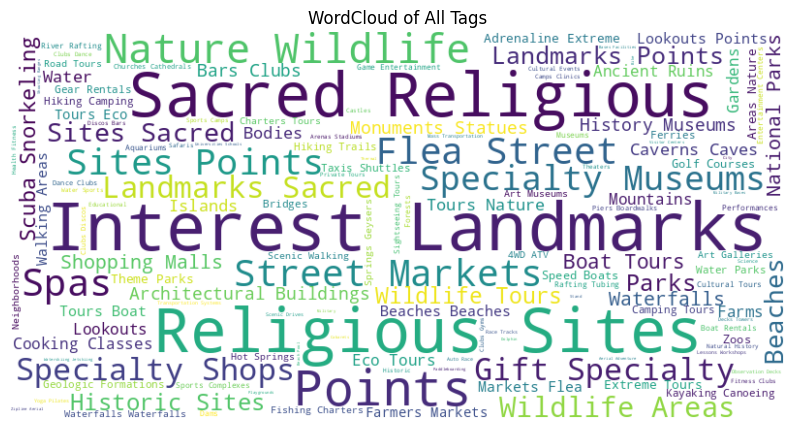

In [66]:
# รวมข้อความทั้งหมดจากคอลัมน์ 'tags'
all_text = " ".join(combined_details_df['tags'].fillna(''))

# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

## Experiment - 1 [TF-IDF + K-MEAN + LDA]

In [72]:
# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_details_df['tags'])

# สร้างโมเดล LDA เพื่อหา topics
lda_model = LatentDirichletAllocation(n_components=N_CLUSTER, random_state=42)  # กำหนด 5 topics
lda_model.fit(X)

# ดึง top keywords ในแต่ละ topic
def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda_model, vectorizer.get_feature_names_out(), n_top_words=10)

# กำหนดกลุ่มให้แต่ละสถานที่
combined_details_df['topic'] = lda_model.transform(X).argmax(axis=1)



/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_5980/2620588952.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


Topic 0:
historic monuments statues buildings gardens sites architectural ruins ancient neighborhoods
Topic 1:
beaches shops gift areas specialty wildlife nature lookouts bodies water
Topic 2:
spas malls shopping farms walking courses golf scenic adrenaline extreme
Topic 3:
parks museums tours specialty national boat scuba snorkeling nature wildlife
Topic 4:
interest points landmarks of mountains sports lookouts aquariums complexes cultural
Topic 5:
sacred religious sites waterfalls ferries forests sightseeing workshops lessons schools
Topic 6:
islands clubs museums bars history caverns caves art galleries bridges
Topic 7:
markets street flea farmers geologic formations churches cathedrals tubing rafting


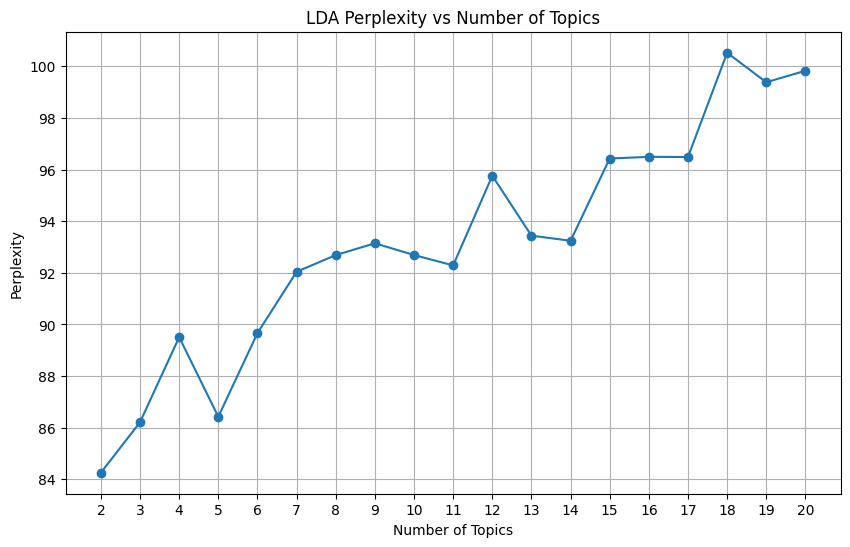

In [73]:
perplexities = []
topic_range = range(2, 21)  # กำหนดช่วงของจำนวนหัวข้อ (2 ถึง 20)

for n_topics in topic_range:
    lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda_model.fit(X)
    perplexities.append(lda_model.perplexity(X))

# การ Visualize ค่า Perplexity
plt.figure(figsize=(10, 6))
plt.plot(topic_range, perplexities, marker='o')
plt.title('LDA Perplexity vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.xticks(topic_range)
plt.grid()
plt.show()

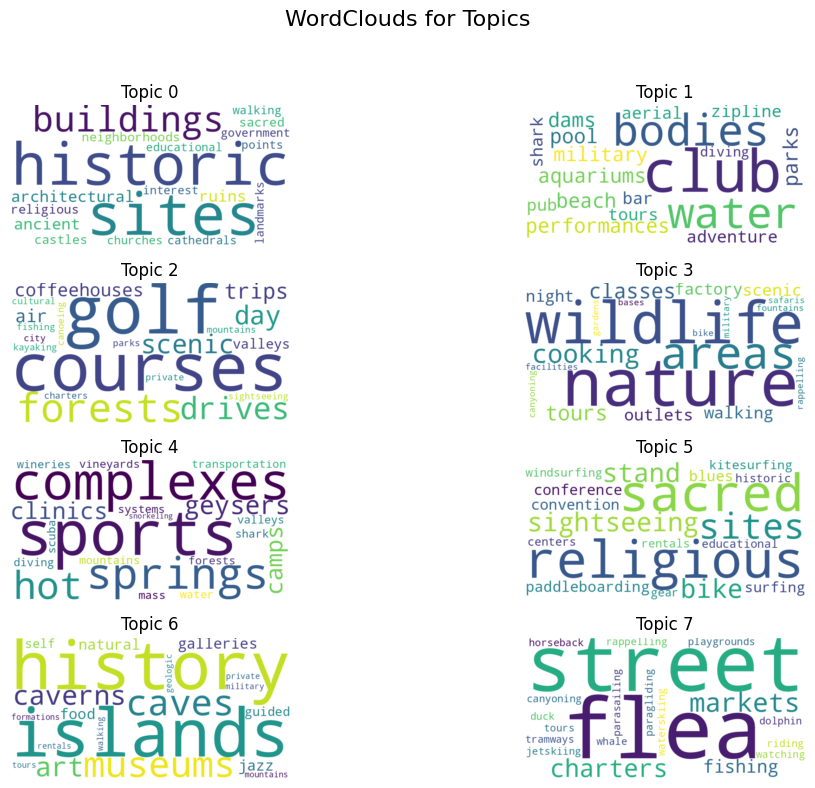

In [74]:
def get_topic_words(lda_model, feature_names, n_top_words=10):
    topic_words = []
    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lda_model, vectorizer.get_feature_names_out(), n_top_words=20)

# Function to plot WordClouds in a 2x2 grid
def plot_wordclouds_in_grid(topic_words, n_rows=2, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16)
    
    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to leave space for title
    plt.show()

# Plot the WordClouds in a 2x2 grid
plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2)

In [75]:
combined_details_df[['name', 'tags', 'topic']]

,name,tags,topic
0,House of Opium,"History Museums, Specialty Museums",6
1,Opium Bar,Bars & Clubs,6
2,Wat Phra That Doi Saket,Sacred & Religious Sites,5
3,Mae Ping River Cruise,Boat Tours,3
4,Pai River,Bodies of Water,1
...,...,...,...
1761,Chao Lao Beach,Beaches,1
1762,Chao Lao Fish Bridge,Bridges,6
1763,Wat Burapa Temple,"Sacred & Religious Sites, Architectural Buildings",0
1764,Kung Wiman Beach,Beaches,1


In [77]:
def advanced_clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in string.punctuation]
    return ' '.join(words)

In [ ]:
combined_details_df = combined_details_df['tags'].replace("", "Other", inplace=True)

In [78]:
cleaned_details_df = combined_details_df['tags'].apply(advanced_clean_text)

cleaned_details_df

0                    history museum specialty museum
1                                           bar club
2                              sacred religious site
3                                          boat tour
4                                         body water
                            ...                     
1761                                           beach
1762                                          bridge
1763    sacred religious site architectural building
1764                                           beach
1765                                         lookout
Name: tags, Length: 1766, dtype: object

In [79]:
# === Import Section ===
# Word embedding and clustering libraries
from gensim.models import Word2Vec
from sklearn.cluster import KMeans

# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt

# === Implementation ===

# Step 1: Train Word2Vec Model
# Tokenize sentences from your dataset
sentences = cleaned_details_df.apply(str.split).tolist()  # Tokenized sentences


In [80]:
sentences

[['history', 'museum', 'specialty', 'museum'],
 ['bar', 'club'],
 ['sacred', 'religious', 'site'],
 ['boat', 'tour'],
 ['body', 'water'],
 ['point', 'interest', 'landmark', 'lookout'],
 ['garden'],
 ['point', 'interest', 'landmark'],
 ['sightseeing', 'tour'],
 ['hot', 'spring', 'geyser'],
 ['national', 'park', 'park'],
 ['flea', 'street', 'market'],
 ['shopping', 'mall'],
 ['specialty', 'museum'],
 ['historic', 'site'],
 ['historic', 'site', 'ancient', 'ruin'],
 ['zoo'],
 ['point', 'interest', 'landmark'],
 ['performance'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['monument', 'statue'],
 ['geologic', 'formation'],
 ['specialty', 'museum'],
 ['architectural', 'building'],
 ['point', 'interest', 'landmark', 'sacred', 'religious', 'site'],
 ['ancient', 'ruin'],
 ['point', 'interest', 'landmark'],
 ['point', 'interest', 'landmark'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['nature', 'wildlife', 'are

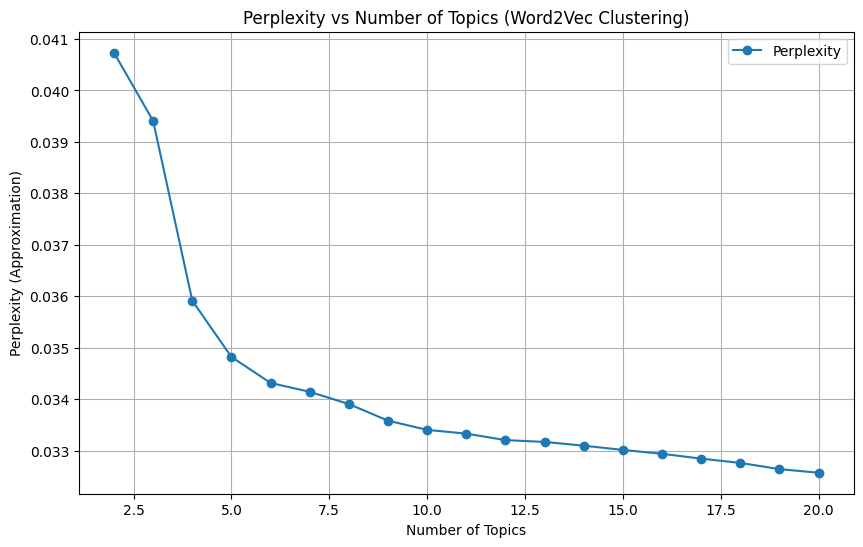

In [81]:

# Train Word2Vec model
word2vec = Word2Vec(sentences, vector_size=300, window=100, min_count=1, workers=4)

# Extract word embeddings and corresponding words
word_vectors = word2vec.wv.vectors  # Word embeddings (array of shape [vocab_size, vector_size])
vocab = word2vec.wv.index_to_key  # List of words corresponding to the embeddings

# Step 2: Function to Cluster Words into Topics
def cluster_words(n_clusters):
    """
    Cluster word vectors using KMeans.
    :param n_clusters: Number of clusters/topics
    :return: KMeans model
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(word_vectors)
    return kmeans

# Step 3: Compute Perplexity Approximation
def compute_perplexity(model, n_clusters):
    """
    Compute a perplexity-like score for the KMeans clustering.
    :param model: Fitted KMeans model
    :param n_clusters: Number of clusters/topics
    :return: Approximation of perplexity (lower is better)
    """
    distances = []
    for i, word in enumerate(vocab):
        word_vector = word_vectors[i]
        cluster_center = model.cluster_centers_[model.labels_[i]]
        distances.append(np.linalg.norm(word_vector - cluster_center))  # Euclidean distance

    avg_distance = np.mean(distances)  # Average distance as a perplexity approximation
    return avg_distance

# Step 4: Evaluate Perplexity for Multiple Numbers of Topics
n_topics_list = range(2, 21)  # Define the range of topic numbers to test
perplexity_scores = []

# Iterate over different numbers of topics
for n_topics in n_topics_list:
    kmeans_model = cluster_words(n_clusters=n_topics)
    perplexity = compute_perplexity(kmeans_model, n_clusters=n_topics)
    perplexity_scores.append(perplexity)

# Step 5: Plot Perplexity vs. Number of Topics
plt.figure(figsize=(10, 6))
plt.plot(n_topics_list, perplexity_scores, marker='o', label="Perplexity")
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity (Approximation)')
plt.title('Perplexity vs Number of Topics (Word2Vec Clustering)')
plt.grid()
plt.legend()
plt.show()


In [82]:
from sklearn.cluster import KMeans
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 1: Cluster Words Using KMeans
def cluster_words(n_clusters, word_vectors):
    """
    Cluster word vectors using KMeans.
    :param n_clusters: Number of clusters/topics
    :param word_vectors: Word embeddings from Word2Vec
    :return: Fitted KMeans model
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(word_vectors)
    return kmeans

# Step 2: Generate Word Clouds for Each Cluster
def generate_word_clouds(model, vocab, output_dir):
    """
    Generate and save word clouds for each cluster.
    :param model: Fitted KMeans model
    :param vocab: Vocabulary corresponding to the word vectors
    :param output_dir: Directory to save the word cloud images
    """
    for cluster_idx in range(model.n_clusters):
        # Aggregate words belonging to the current cluster
        cluster_words = [vocab[i] for i in range(len(vocab)) if model.labels_[i] == cluster_idx]
        cluster_word_str = " ".join(cluster_words)
        
        print(f"\nCluster {cluster_idx}:")
        print(", ".join(cluster_words[:10]))

        # Generate Word Cloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap="viridis"
        ).generate(cluster_word_str)

        # Save Word Cloud Image
        # output_path = f"{output_dir}/word_cloud_cluster_{cluster_idx}.png"
        # wordcloud.to_file(output_path)

        # Display Word Cloud
        # plt.figure(figsize=(10, 6))
        # plt.imshow(wordcloud, interpolation="bilinear")
        # plt.axis("off")
        # plt.title(f"Word Cloud for Cluster {cluster_idx}")
        # plt.show()


In [83]:
from sklearn.metrics.pairwise import cosine_similarity
cos_sim_matrix = cosine_similarity(word2vec.wv.vectors)

In [84]:
kmeans_model = cluster_words(n_clusters=20, word_vectors=word2vec.wv.vectors)


In [86]:
def compute_perplexity_cosine(kmeans_model, word_vectors):
    """
    Compute perplexity for KMeans clustering using cosine similarity on word embeddings.
    :param kmeans_model: Fitted KMeans model on word embeddings
    :param word_vectors: Word2Vec embeddings
    :return: Perplexity approximation (lower is better)
    """
    labels = kmeans_model.labels_
    cluster_centers = kmeans_model.cluster_centers_  # Cluster centers in the same space as word embeddings

    distances = []
    for i, label in enumerate(labels):
        word_vector = word_vectors[i]
        cluster_center = cluster_centers[label]
        
        # Cosine similarity between word vector and cluster center
        cos_sim = cosine_similarity(word_vector.reshape(1, -1), cluster_center.reshape(1, -1))[0][0]
        
        # Convert cosine similarity to distance
        cos_distance = 1 - cos_sim
        distances.append(cos_distance)

    # Average distance as perplexity approximation
    return np.mean(distances)

Clustering with 2 topics...
Clustering with 3 topics...
Clustering with 4 topics...
Clustering with 5 topics...
Clustering with 6 topics...
Clustering with 7 topics...
Clustering with 8 topics...
Clustering with 9 topics...
Clustering with 10 topics...
Clustering with 11 topics...
Clustering with 12 topics...
Clustering with 13 topics...
Clustering with 14 topics...
Clustering with 15 topics...
Clustering with 16 topics...
Clustering with 17 topics...
Clustering with 18 topics...
Clustering with 19 topics...
Clustering with 20 topics...
Clustering with 21 topics...
Clustering with 22 topics...
Clustering with 23 topics...
Clustering with 24 topics...
Clustering with 25 topics...
Clustering with 26 topics...
Clustering with 27 topics...
Clustering with 28 topics...
Clustering with 29 topics...
Clustering with 30 topics...
Clustering with 31 topics...
Clustering with 32 topics...
Clustering with 33 topics...
Clustering with 34 topics...
Clustering with 35 topics...
Clustering with 36 top

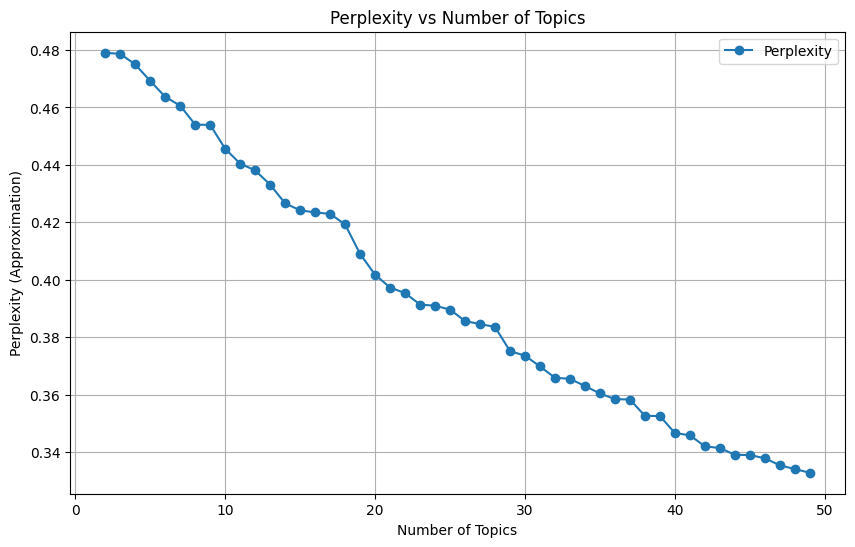

In [101]:
n_topics_range = range(2, 50)  # From 2 to 20 clusters
perplexity_scores = []

# Calculate perplexity for each number of clusters
for n_topics in n_topics_range:
    print(f"Clustering with {n_topics} topics...")
    kmeans_model = cluster_words(n_clusters=n_topics, word_vectors=word_vectors)
    perplexity = compute_perplexity_cosine(kmeans_model, word_vectors)
    perplexity_scores.append(perplexity)

# Plot perplexity vs. number of topics
plt.figure(figsize=(10, 6))
plt.plot(n_topics_range, perplexity_scores, marker='o', label='Perplexity')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity (Approximation)')
plt.title('Perplexity vs Number of Topics')
plt.grid()
plt.legend()
plt.show()

In [100]:
kmeans_model = cluster_words(n_clusters=20, word_vectors=word_vectors)
perplexity = compute_perplexity_cosine(kmeans_model, word2vec.wv.vectors)
print(f"Perplexity (approximation): {perplexity}")

Perplexity (approximation): 0.40177417411045596


In [94]:
word2vec.wv.index_to_key

['landmark',
 'interest',
 'point',
 'site',
 'sacred',
 'religious',
 'tour',
 'specialty',
 'museum',
 'wildlife',
 'nature',
 'park',
 'market',
 'spa',
 'flea',
 'street',
 'beach',
 'area',
 'shop',
 'gift',
 'boat',
 'club',
 'historic',
 'waterfall',
 'water',
 'snorkeling',
 'scuba',
 'lookout',
 'bar',
 'building',
 'national',
 'mall',
 'shopping',
 'architectural',
 'statue',
 'monument',
 'history',
 'body',
 'island',
 'cave',
 'cavern',
 'farm',
 'sport',
 'hiking',
 'ruin',
 'ancient',
 'eco',
 'rental',
 'art',
 'cooking',
 'class',
 'garden',
 'mountain',
 'walking',
 'farmer',
 'scenic',
 'theme',
 'cultural',
 'center',
 'extreme',
 'adrenaline',
 'course',
 'zoo',
 'golf',
 'trail',
 'speed',
 'bridge',
 'canoeing',
 'ferry',
 'formation',
 'kayaking',
 'geologic',
 'camping',
 'shuttle',
 'taxi',
 'gear',
 'game',
 'spring',
 'geyser',
 'complex',
 'charter',
 'neighborhood',
 'gallery',
 'fishing',
 'offroad',
 'atv',
 'wd',
 'hot',
 'aquarium',
 'performance',
 '

In [95]:
generate_word_clouds(kmeans_model, vocab=word2vec.wv.index_to_key, output_dir="./word_clouds")



Cluster 0:
point, sacred, religious, specialty, market, street, bar, history, cave, cavern

Cluster 1:
spa, beach, waterfall, island, farm, garden, mountain, theme, bridge, ferry

Cluster 2:
tour

Cluster 3:
interest, site, museum, nature, park, area, historic, water, sport, ruin

Cluster 4:
wildlife, club, building, architectural, hiking, rental, walking, camping, river, rafting

Cluster 5:
farmer, zoo, neighborhood, performance, theater, arena, event, pilate, workshop, yoga

Cluster 6:
boat, snorkeling, scuba, eco, extreme, adrenaline, speed, canoeing, kayaking, charter

Cluster 7:
landmark, flea, shop, gift, lookout, national, mall, shopping, statue, monument


## Experiment - 2 [Word2Vec + K-Mean]

In [126]:
CONST_VECTOR_SIZE = 100
CONST_DIM_WINDOWS = 5

In [127]:
sentences_2 = sentences

In [128]:
word2vec_model = Word2Vec(sentences_2, vector_size=CONST_VECTOR_SIZE, window=CONST_DIM_WINDOWS, min_count=1, workers=4)

In [129]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# แปลงทุกประโยคเป็นเวกเตอร์
sentence_vectors = np.array([sentence_vector(sentence, word2vec_model) for sentence in sentences_2])


In [130]:
sentence_vectors

array([[ 0.00183485,  0.00842525,  0.00162584, ...,  0.00373667,
         0.00490679, -0.0075743 ],
       [ 0.00979144,  0.00744638, -0.00177992, ..., -0.002144  ,
         0.00255408,  0.0002327 ],
       [-0.00538452,  0.00739163, -0.00464442, ..., -0.00557342,
         0.00178687, -0.00720263],
       ...,
       [-0.00091941,  0.00403859, -0.00513351, ..., -0.00744015,
         0.00273864, -0.00734474],
       [ 0.00162058, -0.00956347,  0.00449574, ..., -0.00264402,
        -0.00767618,  0.00398829],
       [ 0.00325804,  0.00672043, -0.00259538, ...,  0.00379902,
        -0.00757698, -0.00551786]])

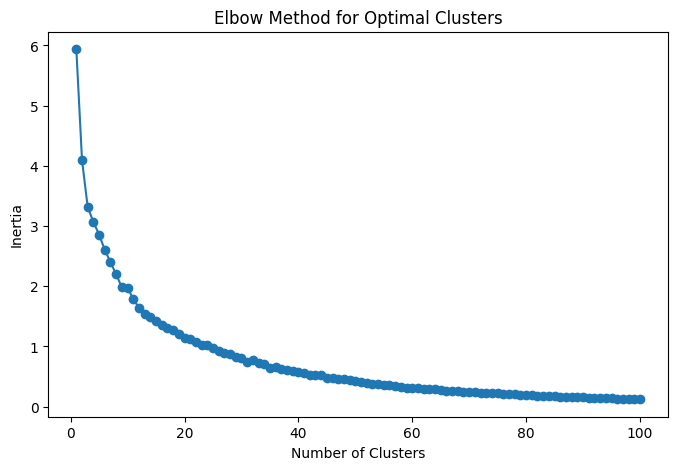

In [131]:
def find_optimal_clusters(data, max_clusters=10):
    inertias = []
    for n in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

    # วาดกราฟ Elbow Method
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_clusters + 1), inertias, marker='o')
    plt.title('Elbow Method for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.show()

find_optimal_clusters(sentence_vectors, max_clusters=100)

จุด "ข้อศอก" ที่เด่นชัดอยู่ประมาณ 10-15 คลัสเตอร์
หลังจากนี้ ค่า Inertia ลดลงในอัตราที่ช้าลง แสดงว่าเพิ่มจำนวนคลัสเตอร์ไปอีกไม่ได้ช่วยปรับปรุงโมเดลอย่างมีนัยสำคัญ


In [161]:
num_clusters = 15
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(sentence_vectors)

ค่า Silhouette Score มีช่วงระหว่าง -1 ถึง 1

ใกล้ 1: การจัดกลุ่มดีมาก (จุดข้อมูลในกลุ่มเดียวกันใกล้กัน และกลุ่มต่าง ๆ ห่างกัน)

ใกล้ 0: จุดข้อมูลอยู่ระหว่างกลุ่มหรือกลุ่มทับซ้อนกัน

ใกล้ -1: การจัดกลุ่มแย่มาก (จุดข้อมูลอยู่ในกลุ่มผิด)

In [162]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(sentence_vectors, labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.5295107914612498


วิธีแปลผลค่า DBI

ใกล้ 0: กลุ่มแยกจากกันชัดเจนและมีความกะทัดรัด

สูง (>1): กลุ่มมีการทับซ้อนหรือไม่มีการแยกที่ชัดเจน

In [163]:
from sklearn.metrics import davies_bouldin_score

dbi_score = davies_bouldin_score(sentence_vectors, labels)
print(f"Davies-Bouldin Index: {dbi_score}")

Davies-Bouldin Index: 1.26990665164236


In [167]:
clusters = {i: [] for i in range(num_clusters)}
for i, label in enumerate(labels):
    clusters[label].append(sentences_2[i])

In [168]:
for cluster_id, items in clusters.items():
    print(f"\nCluster {cluster_id}:")
    print(items)


Cluster 0:
[['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout'], ['lookout']]

Cluster 1:
[['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['shopping', 'mall', 'gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift', 'specialty', 'shop'], ['gift'

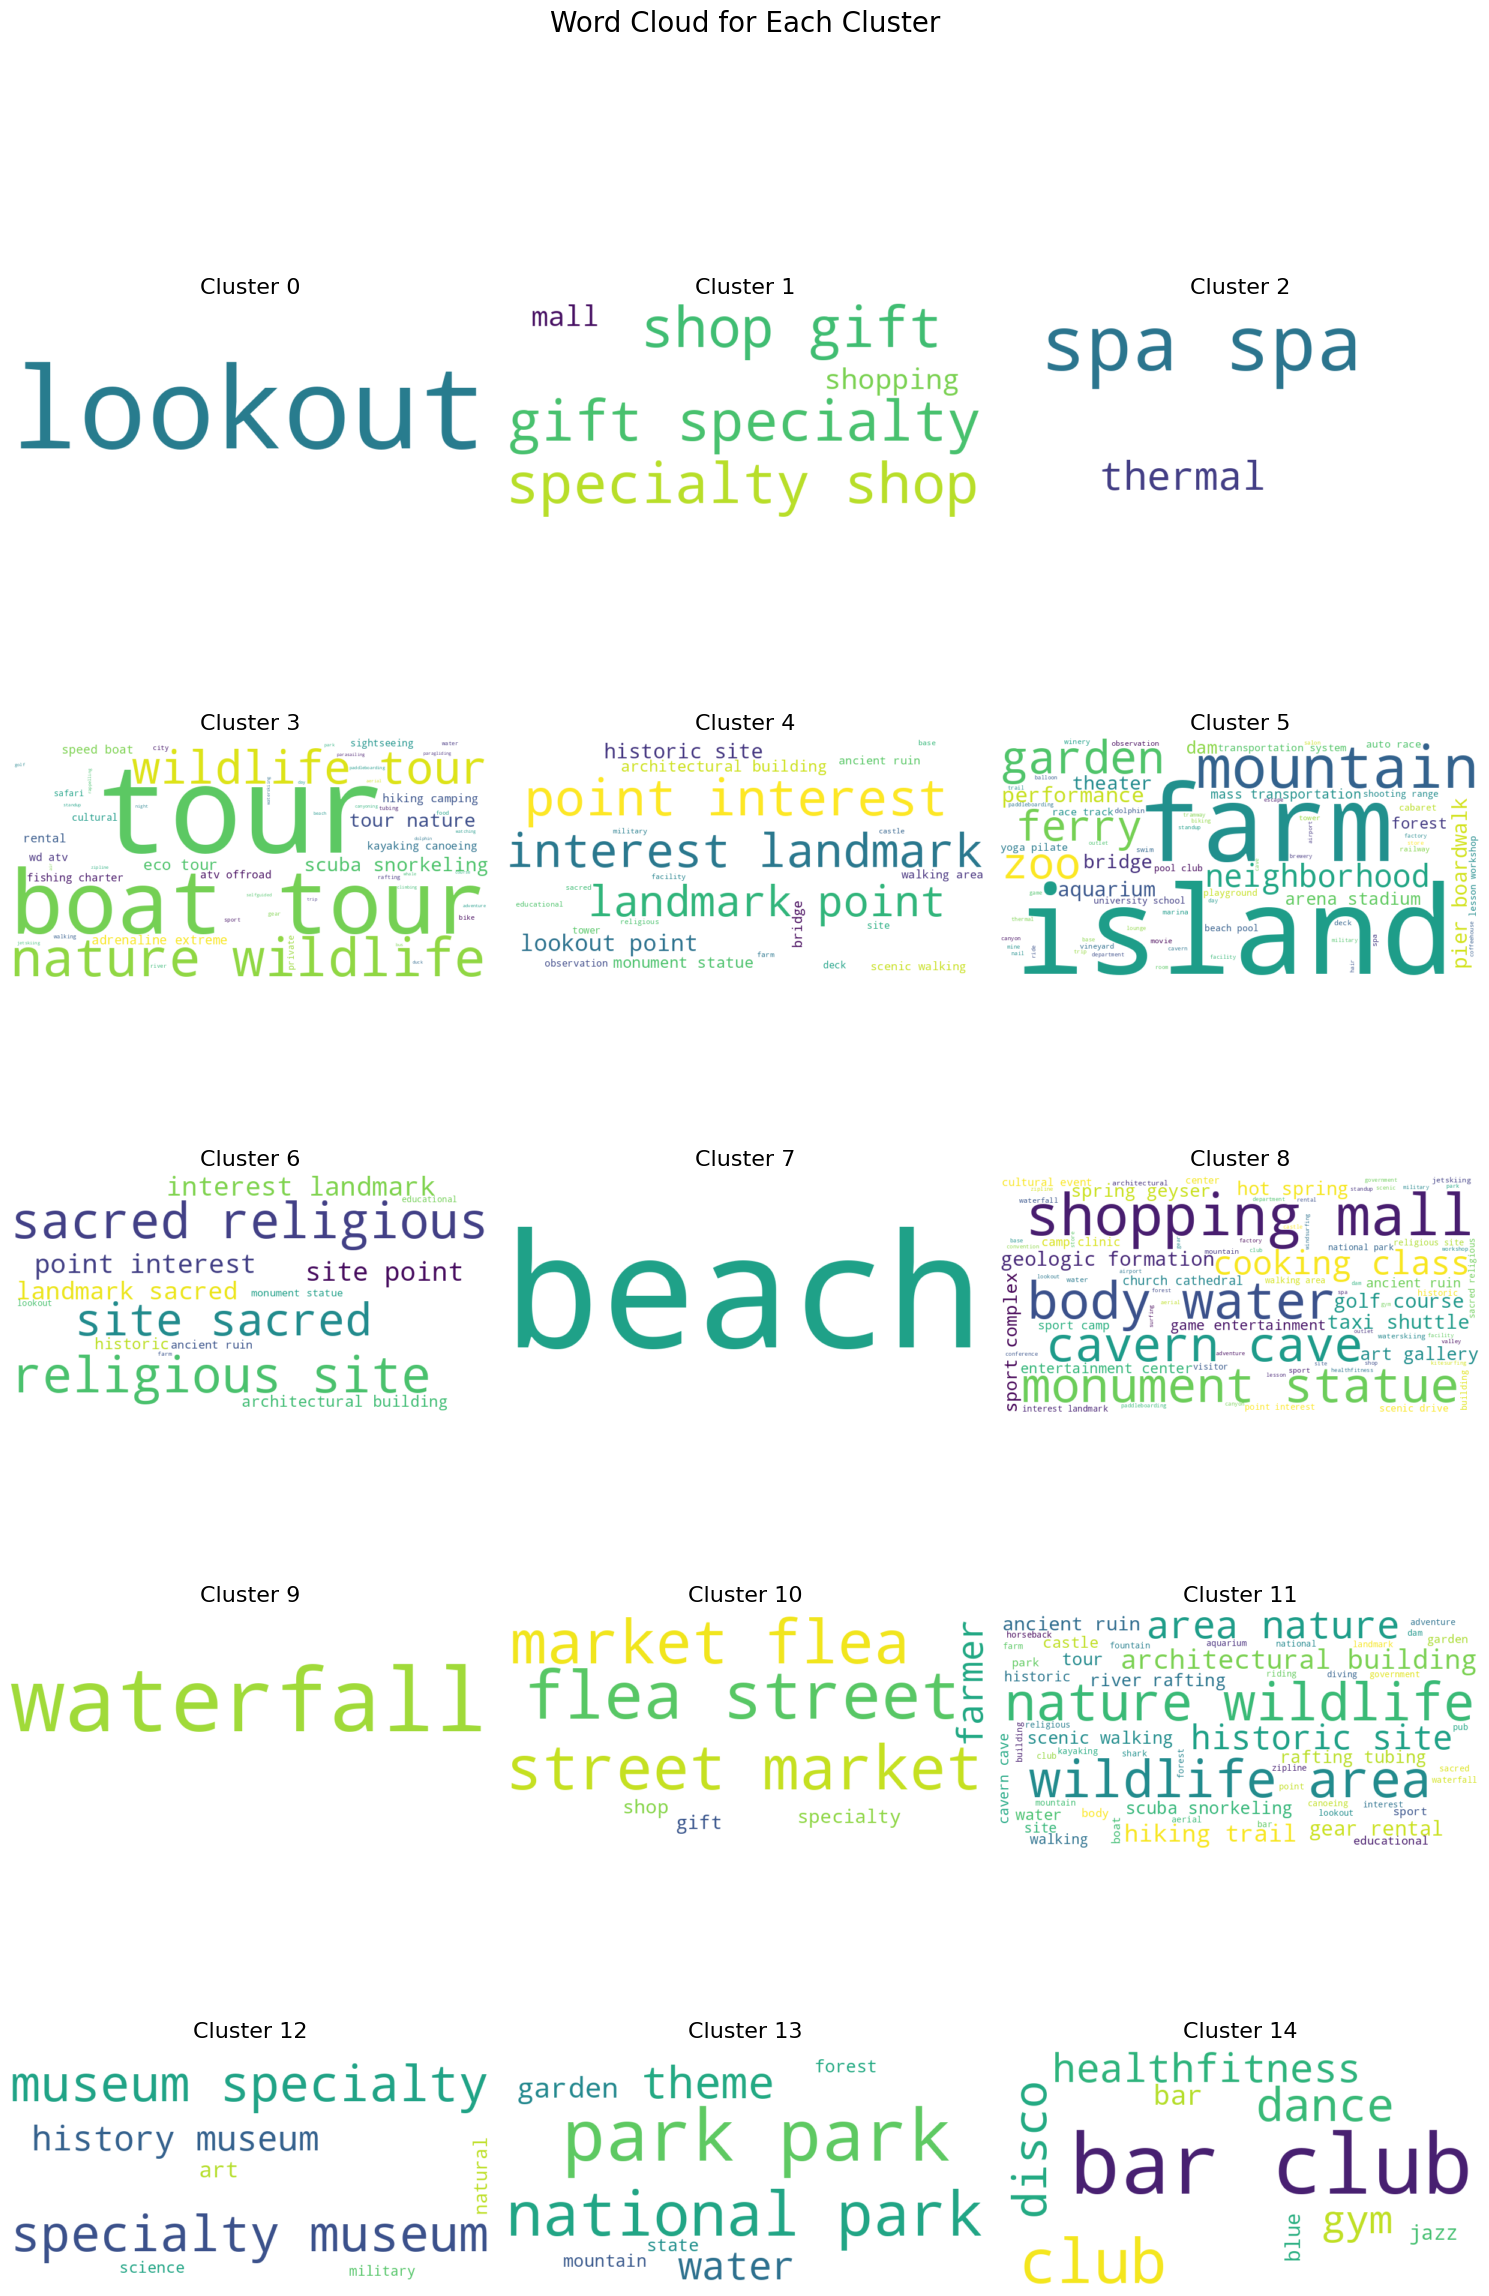

In [172]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

# Process cluster data to ensure all words are flat lists
data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster", fontsize=20)

# Flatten axes for easy iteration (in case rows > 1)
axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()

In [173]:
from collections import Counter

top_words = {
    cluster_id: Counter(words).most_common(1)[0]  # Get the most common word and its count
    for cluster_id, words in data_clusters.items()
}

# Print the top word for each cluster
for cluster_id, (word, count) in top_words.items():
    print(f"Cluster {cluster_id}: Top word is '{word}' with a count of {count}")

Cluster 0: Top word is 'lookout' with a count of 18
Cluster 1: Top word is 'gift' with a count of 65
Cluster 2: Top word is 'spa' with a count of 80
Cluster 3: Top word is 'tour' with a count of 176
Cluster 4: Top word is 'point' with a count of 255
Cluster 5: Top word is 'island' with a count of 26
Cluster 6: Top word is 'site' with a count of 247
Cluster 7: Top word is 'beach' with a count of 75
Cluster 8: Top word is 'shopping' with a count of 30
Cluster 9: Top word is 'waterfall' with a count of 45
Cluster 10: Top word is 'market' with a count of 94
Cluster 11: Top word is 'area' with a count of 67
Cluster 12: Top word is 'museum' with a count of 124
Cluster 13: Top word is 'park' with a count of 88
Cluster 14: Top word is 'club' with a count of 44


## Experiment 3 [Word2Vec + DBSCAN]

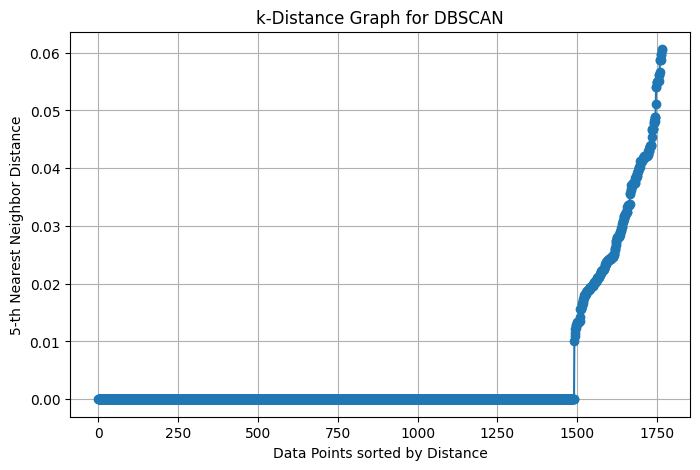

In [178]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

def find_optimal_DBSCAN_eps(data, k=5):
    """
    Uses the k-distance graph to determine the optimal eps value for DBSCAN.

    Parameters:
    - data: numpy array of sentence vectors
    - k: number of nearest neighbors (default: 5)
    """
    # Compute k-nearest neighbors distances
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)

    # Sort the distances to find the optimal elbow point
    sorted_distances = np.sort(distances[:, -1])

    # Plot the k-distance graph
    plt.figure(figsize=(8, 5))
    plt.plot(sorted_distances, marker='o')
    plt.title('k-Distance Graph for DBSCAN')
    plt.xlabel('Data Points sorted by Distance')
    plt.ylabel(f'{k}-th Nearest Neighbor Distance')
    plt.grid()
    plt.show()

find_optimal_DBSCAN_eps(sentence_vectors, k=5)

In [181]:
dbscan_model = DBSCAN(eps=0.02, min_samples=5, metric='euclidean')
labels = dbscan_model.fit_predict(sentence_vectors)

Cluster 0: Top word is 'lookout' with a count of 18
Cluster 1: Top word is 'gift' with a count of 65
Cluster 2: Top word is 'spa' with a count of 80
Cluster 3: Top word is 'tour' with a count of 176
Cluster 4: Top word is 'point' with a count of 255
Cluster 5: Top word is 'island' with a count of 26
Cluster 6: Top word is 'site' with a count of 247
Cluster 7: Top word is 'beach' with a count of 75
Cluster 8: Top word is 'shopping' with a count of 30
Cluster 9: Top word is 'waterfall' with a count of 45
Cluster 10: Top word is 'market' with a count of 94
Cluster 11: Top word is 'area' with a count of 67
Cluster 12: Top word is 'museum' with a count of 124
Cluster 13: Top word is 'park' with a count of 88
Cluster 14: Top word is 'club' with a count of 44
DBSCAN discovered 1 clusters


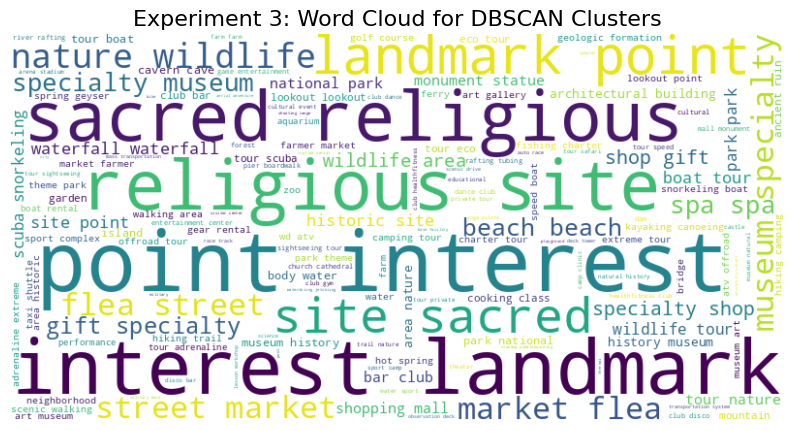

In [174]:
from sklearn.cluster import DBSCAN

# Get the top word of each cluster
top_words = {
    cluster_id: Counter(words).most_common(1)[0]  # Get the most common word and its count
    for cluster_id, words in data_clusters.items()
}

# Print the top word for each cluster
for cluster_id, (word, count) in top_words.items():
    print(f"Cluster {cluster_id}: Top word is '{word}' with a count of {count}")

# Experiment 3: Using DBSCAN for clustering
# Create a dummy embedding data for demonstration purposes
np.random.seed(42)  # For reproducibility
embedding_data = np.random.rand(100, 5)  # 100 samples, 5 dimensions

# DBSCAN clustering
dbscan_model = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
labels = dbscan_model.fit_predict(embedding_data)

# Count the number of clusters discovered
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Exclude noise points
print(f"DBSCAN discovered {num_clusters} clusters")

# Visualize clusters as a word cloud (if applicable)
fig, ax = plt.subplots(figsize=(10, 6))
plt.title("Experiment 3: Word Cloud for DBSCAN Clusters", fontsize=16)

# Example word cloud generation for one of the DBSCAN clusters
example_words = [word for cluster_id, words in data_clusters.items() for word in words]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(example_words))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
plt.show()


In [ ]:
# กำหนดค่าพารามิเตอร์
CONST_MIN_N_CLUSTER = 2
CONST_MAX_N_CLUSTER = 50

# สร้างลิสต์สำหรับเก็บผลลัพธ์
results = []

# วนลูปคำนวณสำหรับแต่ละ n_clusters
for n_clusters in range(CONST_MIN_N_CLUSTER, CONST_MAX_N_CLUSTER + 1):
    # สร้างโมเดล K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sentence_vectors)
    
    # คำนวณ Silhouette Score
    silhouette_avg = silhouette_score(sentence_vectors, labels)
    
    # คำนวณ Davies-Bouldin Index
    dbi_score = davies_bouldin_score(sentence_vectors, labels)
    
    # เก็บผลลัพธ์ในลิสต์
    results.append({
        "n_clusters": n_clusters,
        "Silhouette Score": silhouette_avg,
        "Davies-Bouldin Index": dbi_score
    })

# แปลงผลลัพธ์เป็น DataFrame
results_df = pd.DataFrame(results)

results_df


,n_clusters,Silhouette Score,Davies-Bouldin Index
0,2,0.516234,0.664768
1,3,0.305997,1.439437
2,4,0.336589,1.276868
3,5,0.196747,1.684398
4,6,0.255961,1.550750
5,7,0.293985,1.476379
6,8,0.330736,1.287492
7,9,0.398773,1.472787
8,10,0.398051,1.490024
9,11,0.419235,1.237164


จำนวนคลัสเตอร์ที่เหมาะสมที่สุดคือ:

30-40 คลัสเตอร์: สมดุลทั้ง Silhouette Score และ DBI

หากต้องการคลัสเตอร์ที่มากกว่านั้น (เช่น 50 คลัสเตอร์) ค่า Silhouette Score จะดีที่สุด แต่ควรตรวจสอบความเหมาะสมของข้อมูลเพิ่มเติม

In [ ]:
plt.figure(figsize=(10, 6))

# Plot Silhouette Score
plt.plot(results_df['n_clusters'], results_df['Silhouette Score'], marker='o', label='Silhouette Score')

# Plot Davies-Bouldin Index
plt.plot(results_df['n_clusters'], results_df['Davies-Bouldin Index'], marker='o', label='Davies-Bouldin Index')

plt.title('Silhouette Score and Davies-Bouldin Index vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()